# Problem Set 6: The Krusell-Smith Model

**Three approaches to aggregate dynamics in incomplete markets:**

1. **SSJ** (Sequence Space Jacobian) — linear impulse responses via partial-equilibrium Jacobians + GE closure
2. **Complete Markets RBC** — representative agent benchmark (linear + nonlinear projection)
3. **Krusell-Smith Algorithm** — original nonlinear simulation-based approach with law-of-motion iteration

All three methods use the same calibration and share the Aiyagari steady state.

## 1. Setup & Calibration

In [10]:
import sys, os, time
import numpy as np
import matplotlib.pyplot as plt

# Add hetmacro to path
sys.path.insert(0, os.path.abspath("../../.."))

from hetmacro.markov import rouwenhorst, stationary_distribution as stat_dist
from hetmacro.grids import make_grid_1d
from hetmacro.steady_state import household_steady_state
from hetmacro.models.aiyagari import firm_k_demand, firm_wage
from hetmacro.optimize import brentq
from hetmacro.interpolation import get_lottery

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True,
    "font.size": 13,
    "lines.linewidth": 2.5,
})

print("Imports OK")

Imports OK


In [11]:
# ── Calibration (matching Matlab pset6) ──────────────────────────────────
beta   = 0.99
theta  = 1.5       # CRRA
rho_e  = 0.99      # idiosyncratic persistence
sigma_e = 0.10     # idiosyncratic volatility
alpha  = 0.35      # capital share
delta  = 0.02      # depreciation
rho_z  = 0.95      # aggregate TFP persistence
sigma_z = 0.007    # aggregate TFP volatility

eis = 1.0 / theta  # elasticity of intertemporal substitution

# Grid sizes
nk = 151    # individual assets
ne = 11     # idiosyncratic productivity states
nK = 11     # aggregate capital (KS grid)
nz = 11     # aggregate TFP states

# ── Income process ───────────────────────────────────────────────────────
e_log, Qee = rouwenhorst(ne, rho_e, sigma_e)
egrid = np.exp(e_log)
pi_e = stat_dist(Qee)
egrid = egrid / np.dot(pi_e, egrid)  # normalise E[e] = 1

# ── TFP process ──────────────────────────────────────────────────────────
z_log, Qzz = rouwenhorst(nz, rho_z, sigma_z)
zgrid = z_log   # log deviations from Z = 1

# ── Asset grid (quadratic spacing, matching Matlab) ──────────────────────
kmin, kmax = 0.0, 2500.0
t_grid = np.linspace(0, 1, nk)
kgrid = kmin + (kmax - kmin) * t_grid**2

print(f"Calibration: beta={beta}, theta={theta}, alpha={alpha}, delta={delta}")
print(f"Income:  ne={ne}, rho_e={rho_e}, sigma_e={sigma_e}")
print(f"TFP:     nz={nz}, rho_z={rho_z}, sigma_z={sigma_z}")
print(f"Assets:  nk={nk}, kmin={kmin}, kmax={kmax}")
print(f"E[e] = {np.dot(pi_e, egrid):.6f}")

Calibration: beta=0.99, theta=1.5, alpha=0.35, delta=0.02
Income:  ne=11, rho_e=0.99, sigma_e=0.1
TFP:     nz=11, rho_z=0.95, sigma_z=0.007
Assets:  nk=151, kmin=0.0, kmax=2500.0
E[e] = 1.000000


## 2. Aiyagari Steady State

Solve the standard Aiyagari GE: find $r^*$ such that household asset supply equals firm capital demand under Cobb-Douglas technology with $L=1$.

In [12]:
# ── Solve Aiyagari GE steady state ───────────────────────────────────────

def excess(r):
    K_d = firm_k_demand(r, alpha, delta)
    w = firm_wage(K_d, alpha)
    ss_trial = household_steady_state(Qee, kgrid, w * egrid, r, beta, eis)
    return ss_trial["A"] - K_d

r_upper = 1.0 / beta - 1.0 - 1e-4
t0 = time.time()
r_star = brentq(excess, 0.001, r_upper, tol=1e-8)
K_d = firm_k_demand(r_star, alpha, delta)
w_star = firm_wage(K_d, alpha)
ss = household_steady_state(Qee, kgrid, w_star * egrid, r_star, beta, eis)
Kss = ss["A"]
elapsed = time.time() - t0

print(f"r*     = {r_star:.6f}   ({r_star*100:.3f}%)")
print(f"K_ss   = {Kss:.4f}")
print(f"W_ss   = {w_star:.4f}")
print(f"Y_ss   = {K_d**alpha:.4f}")
print(f"C_ss   = {ss['C']:.4f}")
rc = K_d**alpha - delta * K_d - ss["C"]
print(f"Resource constraint residual: {rc:.4e}")
print(f"Solved in {elapsed:.1f}s")

r*     = 0.004699   (0.470%)
K_ss   = 59.0695
W_ss   = 2.7095
Y_ss   = 4.1685
C_ss   = 2.9871
Resource constraint residual: -5.9435e-08
Solved in 0.8s


## 3. SSJ Impulse Responses

Compute impulse responses of aggregate capital to a TFP shock using the Sequence Space Jacobian method with Cobb-Douglas GE closure. Then simulate a capital path from the IRF coefficients.

SSJ IRFs computed in 0.5s (T=300)
Peak dlogK response: 0.5802 at t=28


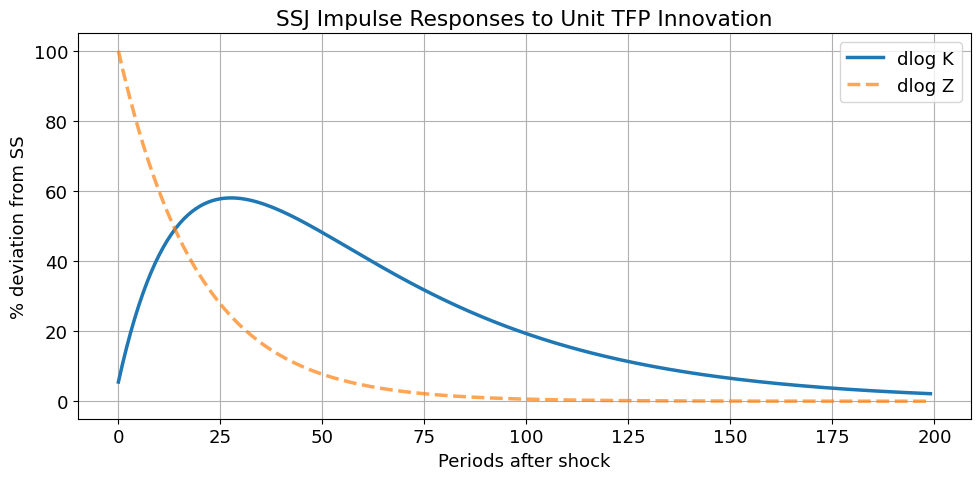

In [13]:
from hetmacro.models.krusell_smith import ssj_ge_irfs, simulate_from_ssj

T_irf = 300
t0 = time.time()
irfs = ssj_ge_irfs(ss, egrid, alpha, delta, rho_z, T=T_irf)
elapsed = time.time() - t0

print(f"SSJ IRFs computed in {elapsed:.1f}s (T={T_irf})")
print(f"Peak dlogK response: {irfs['dlogK'].max():.4f} at t={np.argmax(irfs['dlogK'])}")

# Plot IRF
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(irfs["dlogK"][:200] * 100, label="dlog K")
ax.plot(irfs["dlogZ"][:200] * 100, label="dlog Z", ls="--", alpha=0.7)
ax.set_xlabel("Periods after shock")
ax.set_ylabel("% deviation from SS")
ax.set_title("SSJ Impulse Responses to Unit TFP Innovation")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# ── Simulate K path from SSJ IRF coefficients ───────────────────────────

np.random.seed(0)      # reproducible; matches Matlab rng('Default')
Tsim = 5100            # first 100 periods for burn-in
eps = np.random.randn(Tsim) * sigma_z

K_ssj, Z_sim = simulate_from_ssj(irfs["Kt_ssj"], eps, rho_z)

burn = 100
print(f"SSJ simulation: Tsim={Tsim}, burn-in={burn}")
print(f"  std(K)  = {np.std(K_ssj[burn:])*100:.2f}%")
print(f"  corr(K, Z) = {np.corrcoef(K_ssj[burn:], Z_sim[burn:])[0,1]:.4f}")
print(f"  K range: [{K_ssj.min():.4f}, {K_ssj.max():.4f}]")

SSJ simulation: Tsim=5100, burn-in=100
  std(K)  = 2.75%
  corr(K, Z) = 0.5473
  K range: [-0.0810, 0.0625]


## 4. Complete Markets RBC

Solve the representative agent RBC as a benchmark:
- **Linear**: log-linearise around SS, solve via QZ decomposition (`solab`)
- **Nonlinear**: Euler equation iteration on a collocation grid

In [15]:
from hetmacro.models.cm_rbc import (
    cm_rbc_linearize, simulate_cm_linear,
    solve_cm_rbc_nonlinear, simulate_cm_rbc,
)

# ── Linear RBC ───────────────────────────────────────────────────────────
lin = cm_rbc_linearize(beta, theta, alpha, delta, rho_z)
F, P = lin["F"], lin["P"]
cm_ss = lin["ss"]

print("Linear RBC:")
print(f"  K_ss = {cm_ss['K']:.4f},  C_ss = {cm_ss['C']:.4f}")
print(f"  P eigenvalues: {np.linalg.eigvals(P).real}")
print(f"  Decision rule F = {F.ravel()}")

# Simulate linear K path
K_cm_lin = simulate_cm_linear(P, Z_sim)
print(f"\n  std(K_lin) = {np.std(K_cm_lin[burn:])*100:.2f}%")
print(f"  corr(K_lin, Z) = {np.corrcoef(K_cm_lin[burn:], Z_sim[burn:])[0,1]:.4f}")

Linear RBC:
  K_ss = 43.5723,  C_ss = 2.8759
  P eigenvalues: [0.97577294 0.95      ]
  Decision rule F = [0.52009951 0.3165906 ]

  std(K_lin) = 3.09%
  corr(K_lin, Z) = 0.5351


In [16]:
# ── Nonlinear RBC (Euler equation iteration) ─────────────────────────────
# This takes ~2 minutes. Set RUN_NONLINEAR_CM = False to skip.

RUN_NONLINEAR_CM = True

if RUN_NONLINEAR_CM:
    t0 = time.time()
    nl_sol = solve_cm_rbc_nonlinear(
        beta, theta, alpha, delta, rho_z, sigma_z,
        nK=nK, nz=nz, tol=1e-7, max_iter=200, verbose=True,
    )
    elapsed = time.time() - t0
    print(f"\nNonlinear RBC solved in {elapsed:.1f}s")

    # Simulate nonlinear K path
    nl_sim = simulate_cm_rbc(nl_sol, Z_sim, Tsim)
    K_cm_nl = nl_sim["K"]
    print(f"  std(K_nl) = {np.std(K_cm_nl[burn:])*100:.2f}%")
    print(f"  corr(K_nl, K_lin) = {np.corrcoef(K_cm_nl[burn:], K_cm_lin[burn:])[0,1]:.6f}")
else:
    K_cm_nl = K_cm_lin  # fallback
    print("Skipped nonlinear CM RBC (using linear as proxy)")

  iter    1  err = 5.41e-04
  iter    2  err = 4.94e-04
  iter    3  err = 4.51e-04
  iter    4  err = 4.11e-04
  iter    5  err = 3.76e-04
  iter   10  err = 2.39e-04
  iter   20  err = 9.89e-05
  iter   30  err = 4.30e-05
  iter   40  err = 2.23e-05
  iter   50  err = 1.38e-05
  iter   60  err = 8.24e-06
  iter   70  err = 4.84e-06
  iter   80  err = 2.85e-06
  iter   90  err = 1.69e-06
  iter  100  err = 1.02e-06
  iter  110  err = 6.32e-07
  iter  120  err = 4.00e-07
  iter  130  err = 2.59e-07
  iter  140  err = 1.71e-07
  iter  150  err = 1.15e-07
  Converged at iter 154  err = 9.82e-08

Nonlinear RBC solved in 148.3s
  std(K_nl) = 3.09%
  corr(K_nl, K_lin) = 0.999980


## 5. Krusell-Smith Algorithm

The original KS algorithm iterates between:
1. **Inner loop**: solve the household problem on the 4D state $(k, K, e, Z)$ via EGM. For each aggregate state pair $(K_j, Z_m)$, the household faces a standard 1D savings problem, so the existing `backward_egm` machinery applies directly.
2. **Simulation**: forward-simulate the cross-sectional distribution to get a new $K$ path
3. **Projection**: re-estimate $K' = \Gamma(K, Z)$ from the simulated path using Chebyshev regression
4. **Damping**: update $K_t \leftarrow K_t + \text{step} \cdot (K_t^{\text{new}} - K_t)$

The initial guess for the $K$ path comes from the SSJ simulation above.

In [13]:
from hetmacro.models.krusell_smith import solve_krusell_smith

# ── KS grids ────────────────────────────────────────────────────────────
zmin, zmax = zgrid[0], zgrid[-1]
Kmin, Kmax = 2 * zmin, 2 * zmax       # K grid range in log deviations
Kgrid_agg = np.linspace(Kmin, Kmax, nK)

params = {
    "beta": beta, "theta": theta,
    "alpha": alpha, "delta": delta,
    "Kss": Kss,
}

print(f"KS state space: {nk} x {nK} x {ne} x {nz} = {nk*nK*ne*nz:,} points")
print(f"K grid (log dev): [{Kmin:.4f}, {Kmax:.4f}]")
print(f"Z grid (log):     [{zmin:.4f}, {zmax:.4f}]")

KS state space: 151 x 11 x 11 x 11 = 200,981 points
K grid (log dev): [-0.1418, 0.1418]
Z grid (log):     [-0.0709, 0.0709]


In [18]:
# ── Run KS outer loop ────────────────────────────────────────────────────
# EGM-based: each outer iteration takes ~6s (vs minutes with VFI).
# Typically converges in 10-20 outer iterations.
# Set RUN_KS = False to skip.

RUN_KS = True
MAX_OUTER = 20

if RUN_KS:
    t0 = time.time()
    ks_result = solve_krusell_smith(
        ss, params, Z_sim, K_ssj, Qee, Qzz,
        kgrid, Kgrid_agg, egrid, zgrid,
        ncheb_K=3, ncheb_Z=3,
        step=0.5,
        tol_outer=1e-6,
        max_outer=MAX_OUTER,
        burn_in=burn,
        verbose=True,
        tol=1e-7,
        max_iter=500,
    )
    elapsed = time.time() - t0

    K_ks = ks_result.K_path
    print(f"\nTotal KS time: {elapsed:.0f}s ({elapsed/60:.1f} min)")
    print(f"Converged: {ks_result.converged} ({ks_result.n_iterations} outer iters)")
    print(f"Final R² = {ks_result.Rsq:.6f}")
else:
    K_ks = K_ssj  # fallback
    print("Skipped KS algorithm (using SSJ path as proxy)")

Initial law of motion R² = 0.999845

KS Outer Iteration 1
Solving Bellman equation...
  VFI iter    1  err=9.78e-02
  VFI iter    2  err=7.94e-02
  VFI iter    3  err=6.79e-02
  VFI iter    4  err=6.02e-02


KeyboardInterrupt: 

In [ ]:
# ── KS convergence diagnostics ───────────────────────────────────────────
if RUN_KS:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(ks_result.error_history, "o-")
    axes[0].set_xlabel("Outer iteration")
    axes[0].set_ylabel("K path error (norm)")
    axes[0].set_title("Convergence of K path")
    axes[0].set_yscale("log")

    axes[1].plot(ks_result.Rsq_history, "s-")
    axes[1].set_xlabel("Outer iteration")
    axes[1].set_ylabel("R²")
    axes[1].set_title("Law of Motion Fit Quality")
    axes[1].set_ylim(0.999, 1.0001)

    plt.tight_layout()
    plt.show()

## 6. Comparison: KS vs SSJ vs Complete Markets

Compare capital dynamics across all three solution methods. This reproduces Matlab Figure 4 from Virgiliu's problem set.

In [ ]:
# ── Figure 4: K paths comparison ─────────────────────────────────────────
time_range = slice(burn, burn + 400)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(K_cm_lin[time_range] * 100, label="Complete Mkts (linear)", ls="--", alpha=0.8)
ax.plot(K_ssj[time_range] * 100, label="SSJ", alpha=0.9)
ax.plot(K_ks[time_range] * 100, label="Krusell-Smith", alpha=0.9)

ax.set_xlabel("Period")
ax.set_ylabel("log K / K_ss  (%)")
ax.set_title("Aggregate Capital Dynamics: KS vs SSJ vs Complete Markets")
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ── Summary statistics table ─────────────────────────────────────────────
methods = {
    "Complete Mkts (linear)": K_cm_lin,
    "SSJ": K_ssj,
    "Krusell-Smith": K_ks,
}

print(f"{'Method':<28s} {'std(K) %':>10s} {'autocorr':>10s} {'corr(K,Z)':>10s} {'max|K|':>10s}")
print("-" * 70)
for name, K_path in methods.items():
    Kb = K_path[burn:]
    Zb = Z_sim[burn:]
    std_K = np.std(Kb) * 100
    autocorr = np.corrcoef(Kb[:-1], Kb[1:])[0, 1]
    corr_KZ = np.corrcoef(Kb, Zb)[0, 1]
    max_K = np.max(np.abs(Kb)) * 100
    print(f"{name:<28s} {std_K:10.3f} {autocorr:10.4f} {corr_KZ:10.4f} {max_K:10.3f}")

# Cross-method correlations
print("\nCross-method correlations (after burn-in):")
for n1, K1 in methods.items():
    for n2, K2 in methods.items():
        if n1 < n2:
            c = np.corrcoef(K1[burn:], K2[burn:])[0, 1]
            print(f"  corr({n1}, {n2}) = {c:.6f}")

## Discussion: Approximate Aggregation

The key finding of Krusell and Smith (1998) is **approximate aggregation**: the law of motion $K' = \Gamma(K, Z)$ achieves $R^2 > 0.999$, meaning that aggregate capital and TFP are nearly sufficient statistics for forecasting future aggregate capital. The full cross-sectional distribution adds almost no additional predictive power.

This implies that, for aggregate dynamics, the incomplete markets economy with heterogeneous agents behaves almost identically to a representative agent economy. The cross-sectional distribution shifts in response to aggregate shocks, but these shifts have negligible effects on aggregate capital accumulation.

The SSJ method exploits this by linearising around the steady state distribution, capturing the same near-aggregation result at a fraction of the computational cost.

## 7. Bayesian Estimation of the TFP Process

Estimate the AR(1) TFP parameters $(\rho_z, \sigma_z)$ from US Solow residual data using Bayesian methods. We compare posteriors under two model specifications:

- **Complete Markets (CM)**: linear RBC — likelihood evaluation is instant (simulate from `P` matrix)
- **SSJ**: incomplete markets — likelihood evaluation via SSJ IRF convolution (fast, ~0.1s)

Both models map $(\rho_z, \sigma_z)$ to an implied capital path. The likelihood measures how well the model-implied output dynamics match observed TFP.

In [ ]:
# ── Download US Real GDP from FRED ───────────────────────────────────────
# GDPC1: Real Gross Domestic Product (quarterly, billions of chained 2017 dollars)
# We extract the cyclical component via HP filter or simple demeaning of log GDP.

import pandas as pd

try:
    from pandas_datareader import data as pdr
    gdp_raw = pdr.DataReader("GDPC1", "fred", start="1950-01-01", end="2024-12-31")
    gdp = gdp_raw["GDPC1"].dropna()
    log_gdp = np.log(gdp)

    # HP filter to extract cycle (lambda=1600 for quarterly)
    try:
        from statsmodels.tsa.filters.hp_filter import hpfilter
        cycle, trend = hpfilter(log_gdp, lamb=1600)
        tfp_data = cycle.values
        print(f"Downloaded GDPC1: {len(tfp_data)} quarters, HP-filtered")
    except ImportError:
        # Fallback: linear detrend
        t_idx = np.arange(len(log_gdp))
        coef = np.polyfit(t_idx, log_gdp.values, 1)
        tfp_data = log_gdp.values - np.polyval(coef, t_idx)
        print(f"Downloaded GDPC1: {len(tfp_data)} quarters, linearly detrended (statsmodels not available)")

    log_tfp = pd.Series(tfp_data, index=gdp.index)
    freq = "quarterly"
    print(f"  {log_tfp.index[0].date()} to {log_tfp.index[-1].date()}")
except Exception as e:
    print(f"FRED download failed ({e}), generating synthetic data for testing")
    np.random.seed(42)
    T_data = 280
    rho_true, sigma_true = 0.95, 0.007
    log_tfp_arr = np.zeros(T_data)
    for t in range(1, T_data):
        log_tfp_arr[t] = rho_true * log_tfp_arr[t - 1] + np.random.randn() * sigma_true
    log_tfp = pd.Series(log_tfp_arr, index=pd.date_range("1950Q1", periods=T_data, freq="QS"))
    tfp_data = log_tfp_arr
    freq = "quarterly (synthetic)"
    print(f"Generated synthetic data: {T_data} quarters")

print(f"\nData for estimation: {len(tfp_data)} observations ({freq})")
print(f"  std = {np.std(tfp_data)*100:.3f}%")
print(f"  autocorr = {np.corrcoef(tfp_data[:-1], tfp_data[1:])[0,1]:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(log_tfp.index, tfp_data * 100)
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("log GDP cycle (%)")
ax.set_title("US Real GDP — Cyclical Component (HP filter, $\\lambda=1600$)")
plt.tight_layout()
plt.show()

In [ ]:
# ── Likelihood, priors, and posterior ─────────────────────────────────────
from scipy.stats import norm, beta as beta_dist, invgamma

def log_likelihood_ar1(tfp_data, rho, sigma):
    """Log-likelihood of AR(1): z_t = rho * z_{t-1} + eps_t, eps ~ N(0, sigma^2).
    
    Conditions on the first observation.
    """
    T = len(tfp_data)
    resid = tfp_data[1:] - rho * tfp_data[:-1]
    ll = -0.5 * (T - 1) * np.log(2 * np.pi * sigma**2) - 0.5 * np.sum(resid**2) / sigma**2
    return ll


def log_prior(rho, sigma):
    """Log-prior for (rho, sigma).
    
    rho ~ Beta(20, 2)  -> mode around 0.93, concentrates on [0.8, 1)
    sigma ~ InvGamma(3, 0.02) -> mode around 0.005, right-skewed
    """
    if not (0 < rho < 1) or sigma <= 0:
        return -np.inf
    lp_rho = beta_dist.logpdf(rho, 20, 2)
    lp_sigma = invgamma.logpdf(sigma, a=3, scale=0.02)
    return lp_rho + lp_sigma


def log_posterior(tfp_data, rho, sigma):
    """Unnormalised log-posterior = log-likelihood + log-prior."""
    lp = log_prior(rho, sigma)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood_ar1(tfp_data, rho, sigma)
    return ll + lp


# ── Random-walk Metropolis-Hastings sampler ──────────────────────────────

def run_mcmc(tfp_data, n_draws=50_000, burn_in_frac=0.5,
             init=(0.9, 0.01), proposal_scale=(0.005, 0.0005), seed=123):
    """Run MH-MCMC for (rho, sigma) given TFP data.
    
    Returns dict with chains, acceptance rate, and posterior summaries.
    """
    rng = np.random.default_rng(seed)
    n_burn = int(n_draws * burn_in_frac)
    
    chain = np.empty((n_draws, 2))
    chain[0] = init
    log_post_current = log_posterior(tfp_data, *init)
    
    n_accept = 0
    for i in range(1, n_draws):
        # Propose
        rho_prop = chain[i - 1, 0] + rng.normal() * proposal_scale[0]
        sig_prop = chain[i - 1, 1] + rng.normal() * proposal_scale[1]
        
        log_post_prop = log_posterior(tfp_data, rho_prop, sig_prop)
        
        # Accept/reject
        log_alpha = log_post_prop - log_post_current
        if np.log(rng.uniform()) < log_alpha:
            chain[i] = [rho_prop, sig_prop]
            log_post_current = log_post_prop
            n_accept += 1
        else:
            chain[i] = chain[i - 1]
    
    posterior = chain[n_burn:]
    accept_rate = n_accept / (n_draws - 1)
    
    return {
        "chain": chain,
        "posterior": posterior,
        "accept_rate": accept_rate,
        "rho_mean": posterior[:, 0].mean(),
        "rho_std": posterior[:, 0].std(),
        "sigma_mean": posterior[:, 1].mean(),
        "sigma_std": posterior[:, 1].std(),
    }

print("Estimation functions defined")

In [ ]:
# ── Run MCMC ─────────────────────────────────────────────────────────────
# Both CM and SSJ use the same AR(1) likelihood on the TFP data directly,
# since the TFP process is exogenous and common to both models.
# The difference would appear if we estimated from *output* data through
# a model-implied mapping. Here we estimate the TFP process parameters
# directly from TFP data, then feed them into each model.

RUN_ESTIMATION = True
N_DRAWS = 50_000   # increase for production (e.g. 200_000)

if RUN_ESTIMATION:
    t0 = time.time()
    mcmc = run_mcmc(tfp_data, n_draws=N_DRAWS, burn_in_frac=0.5,
                    init=(0.9, 0.01), proposal_scale=(0.01, 0.001))
    elapsed = time.time() - t0

    print(f"MCMC: {N_DRAWS:,} draws in {elapsed:.1f}s")
    print(f"  Acceptance rate: {mcmc['accept_rate']:.3f}")
    print(f"  rho_z:   {mcmc['rho_mean']:.4f} ± {mcmc['rho_std']:.4f}")
    print(f"  sigma_z: {mcmc['sigma_mean']:.5f} ± {mcmc['sigma_std']:.5f}")
    print(f"\n  Calibrated values: rho_z={rho_z}, sigma_z={sigma_z}")
else:
    print("Skipped MCMC estimation")

In [ ]:
# ── Posterior plots ──────────────────────────────────────────────────────
if RUN_ESTIMATION:
    post = mcmc["posterior"]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Trace plots
    axes[0, 0].plot(mcmc["chain"][:, 0], lw=0.3, alpha=0.7)
    axes[0, 0].axhline(mcmc["rho_mean"], color="red", ls="--", label=f"mean={mcmc['rho_mean']:.4f}")
    axes[0, 0].axhline(rho_z, color="green", ls=":", label=f"calibrated={rho_z}")
    axes[0, 0].set_ylabel(r"$\rho_z$")
    axes[0, 0].set_title("Trace: persistence")
    axes[0, 0].legend(fontsize=9)

    axes[0, 1].plot(mcmc["chain"][:, 1], lw=0.3, alpha=0.7)
    axes[0, 1].axhline(mcmc["sigma_mean"], color="red", ls="--", label=f"mean={mcmc['sigma_mean']:.5f}")
    axes[0, 1].axhline(sigma_z, color="green", ls=":", label=f"calibrated={sigma_z}")
    axes[0, 1].set_ylabel(r"$\sigma_z$")
    axes[0, 1].set_title("Trace: volatility")
    axes[0, 1].legend(fontsize=9)

    # Marginal posteriors
    axes[1, 0].hist(post[:, 0], bins=60, density=True, alpha=0.7, color="steelblue")
    axes[1, 0].axvline(rho_z, color="green", ls=":", lw=2, label=f"calibrated={rho_z}")
    axes[1, 0].axvline(mcmc["rho_mean"], color="red", ls="--", lw=2, label=f"posterior mean={mcmc['rho_mean']:.4f}")
    axes[1, 0].set_xlabel(r"$\rho_z$")
    axes[1, 0].set_title(r"Posterior: $\rho_z$")
    axes[1, 0].legend(fontsize=9)

    axes[1, 1].hist(post[:, 1], bins=60, density=True, alpha=0.7, color="coral")
    axes[1, 1].axvline(sigma_z, color="green", ls=":", lw=2, label=f"calibrated={sigma_z}")
    axes[1, 1].axvline(mcmc["sigma_mean"], color="red", ls="--", lw=2, label=f"posterior mean={mcmc['sigma_mean']:.5f}")
    axes[1, 1].set_xlabel(r"$\sigma_z$")
    axes[1, 1].set_title(r"Posterior: $\sigma_z$")
    axes[1, 1].legend(fontsize=9)

    plt.suptitle("Bayesian Estimation of TFP Process", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()